### 16 simple features extracted from docs
(in `data/features/`)

In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

root = '/juice5b/scr5b/kaitwang/stats305c/WebOrganizer/milestone2'

df = pd.concat([pd.read_parquet(f) for f in sorted(glob.glob(f'{root}/data/features/*.parquet'))], ignore_index=True)
print(df.shape); df.head()

(2263456, 20)


,doc_idx,url,url_netloc,url_registered_domain,char_count,word_count,mean_word_length,frac_alpha,frac_digit,frac_punctuation,frac_uppercase,frac_lines_terminal_punct,frac_lines_bullet,type_token_ratio,stopword_fraction,ngram_rep_2,ngram_rep_3,ngram_rep_4,num_lines,mean_line_length
0,0,http://1-slot-machine-wins.youtubetomp3convert...,1-slot-machine-wins.youtubetomp3converter.us,youtubetomp3converter.us,1922,340,4.644118,0.803330,0.002601,0.014048,0.037565,0.173913,0.000000,0.614706,0.376471,0.123529,0.000000,0.000000,27,70.222222
1,1,http://4amazingthings.com/the-order-of-the-pre...,4amazingthings.com,4amazingthings.com,2032,311,5.520900,0.816437,0.007382,0.017717,0.040386,0.500000,0.000000,0.559486,0.398714,0.372990,0.260450,0.205788,11,183.818182
2,2,http://6ryl-sessions.over-blog.com/2013/10/day...,6ryl-sessions.over-blog.com,over-blog.com,523,89,4.707865,0.697897,0.028681,0.074570,0.095890,0.200000,0.000000,0.921348,0.224719,0.000000,0.000000,0.000000,26,19.153846
3,3,http://academicwritinglibrarian.blogspot.com/2...,academicwritinglibrarian.blogspot.com,blogspot.com,1195,215,4.525581,0.784100,0.015063,0.014226,0.035219,0.333333,0.000000,0.618605,0.409302,0.186047,0.111628,0.037209,14,84.428571
4,4,http://accessus.net/business-services/st-louis...,accessus.net,accessus.net,3620,564,5.384752,0.791713,0.014917,0.022376,0.092114,0.200000,0.555556,0.542553,0.221631,0.273050,0.127660,0.028369,65,54.707692


In [3]:
[pd.read_parquet(f) for f in sorted(glob.glob(f'{root}/data/features/*.parquet'))]


[       doc_idx                                                url  \
 0            0  http://1-slot-machine-wins.youtubetomp3convert...   
 1            1  http://4amazingthings.com/the-order-of-the-pre...   
 2            2  http://6ryl-sessions.over-blog.com/2013/10/day...   
 3            3  http://academicwritinglibrarian.blogspot.com/2...   
 4            4  http://accessus.net/business-services/st-louis...   
 ...        ...                                                ...   
 16026    16026  https://yoyoknows.com/2017/09/25/home-automati...   
 16027    16027  https://yubin.livejournal.com/51160.html?threa...   
 16028    16028  https://zmab15.com/2015/03/20/a-new-category-o...   
 16029    16029  https://zombiesintelligently.com/2013/07/11/co...   
 16030    16030                                   https://zone.tv/   
 
                                          url_netloc     url_registered_domain  \
 0      1-slot-machine-wins.youtubetomp3converter.us  youtubetomp3converter.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
doc_idx,2263456.0,11938.305716,7596.624757,0.000000,5658.000000,11317.000000,17318.000000,40596.000000
char_count,2263456.0,3741.270224,8115.355523,14.000000,988.000000,2015.000000,3938.000000,699575.000000
word_count,2263456.0,626.675848,1372.916785,2.000000,162.000000,332.000000,655.000000,108333.000000
mean_word_length,2263456.0,4.995627,0.489865,2.396552,4.657071,4.951374,5.272727,27.666667
frac_alpha,2263456.0,0.772670,0.033147,0.002434,0.757083,0.778473,0.795068,0.902682
frac_digit,2263456.0,0.016587,0.018634,0.000000,0.004245,0.010536,0.022477,0.615894
frac_punctuation,2263456.0,0.029677,0.012422,0.000000,0.021492,0.027189,0.035009,0.396268
frac_uppercase,2263456.0,0.061512,0.032278,0.000000,0.038899,0.054366,0.076799,0.888889
frac_lines_terminal_punct,2263456.0,0.429004,0.244313,0.000000,0.233333,0.411765,0.611111,1.000000
frac_lines_bullet,2263456.0,0.088705,0.165486,0.000000,0.000000,0.000000,0.115385,1.000000


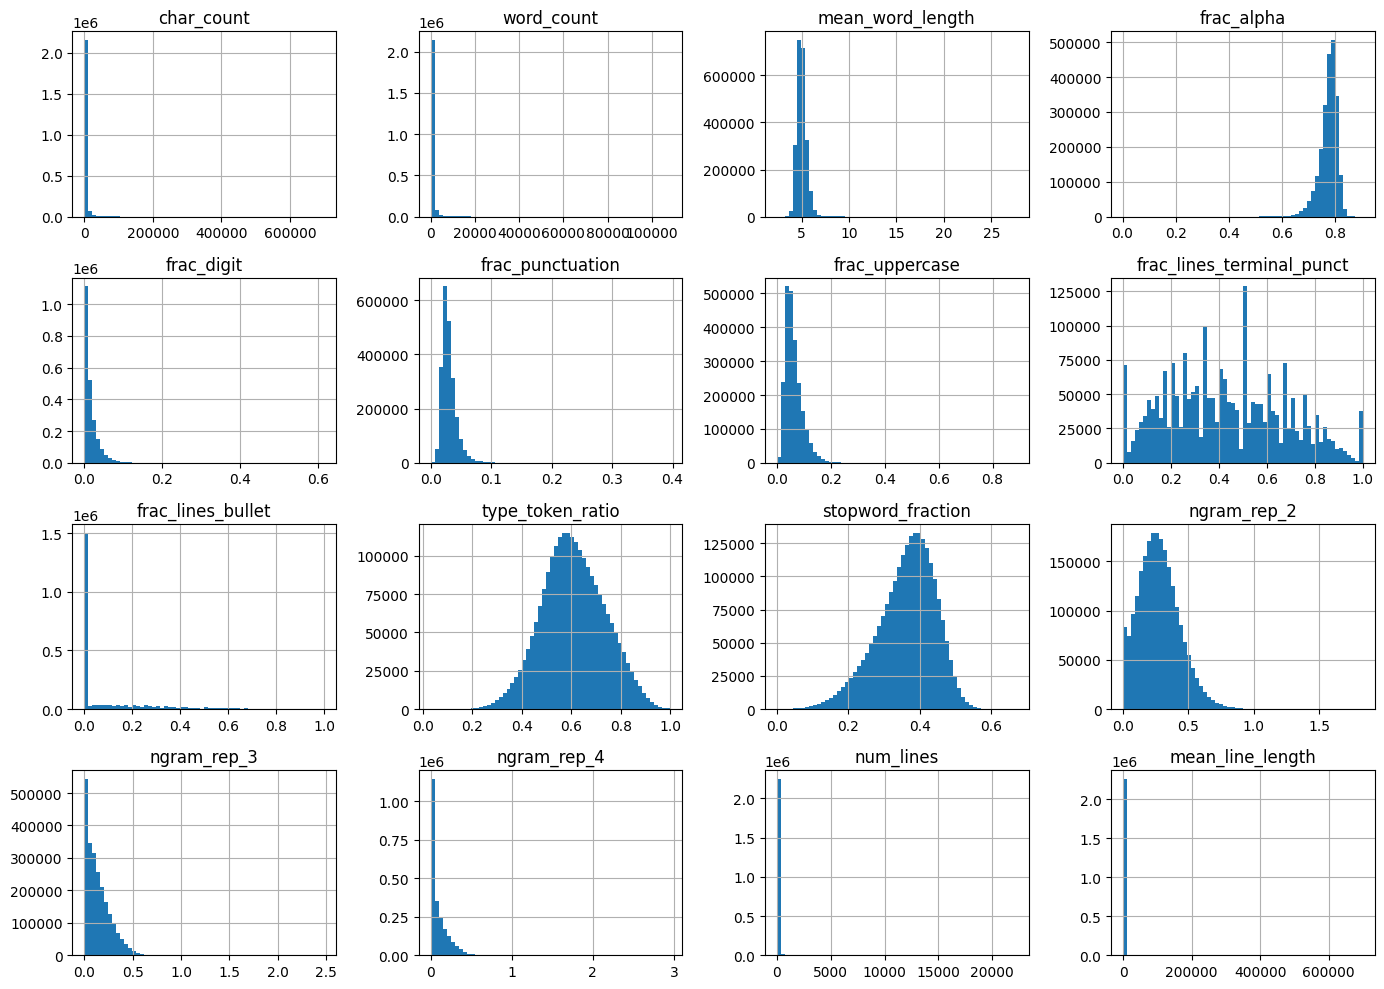

In [5]:
import sys
sys.path.insert(0, "/juice5b/scr5b/kaitwang/stats305c/WebOrganizer/milestone2")
from Heuristics import FEATURE_COLS
df[FEATURE_COLS].hist(bins=60, figsize=(14, 10), log=False); plt.tight_layout()

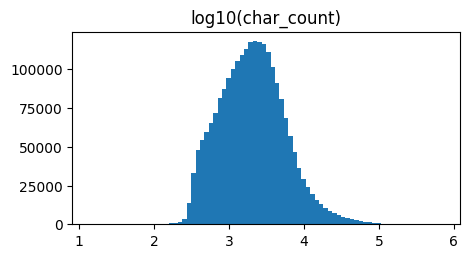

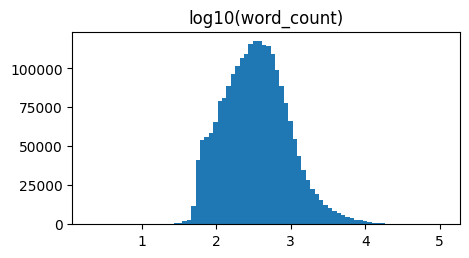

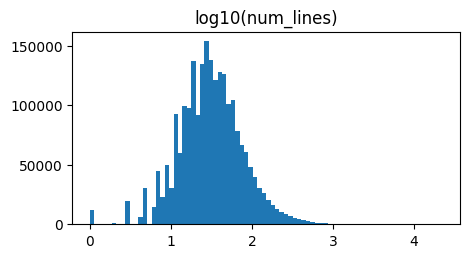

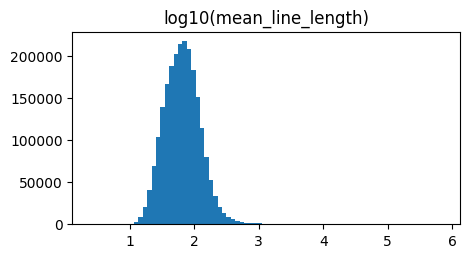

In [6]:
# log scale for the heavy tailed features
import numpy as np
for c in ['char_count', 'word_count', 'num_lines', 'mean_line_length']:
    plt.figure(figsize=(5,2.5))
    plt.hist(np.log10(df[c].clip(lower=1)), bins=80)
    plt.title(f'log10({c})'); plt.show()

unique: 798,128   >=100 docs: 1,877   >=1000 docs: 38


Text(0.5, 1.0, 'registered-domain Zipf')

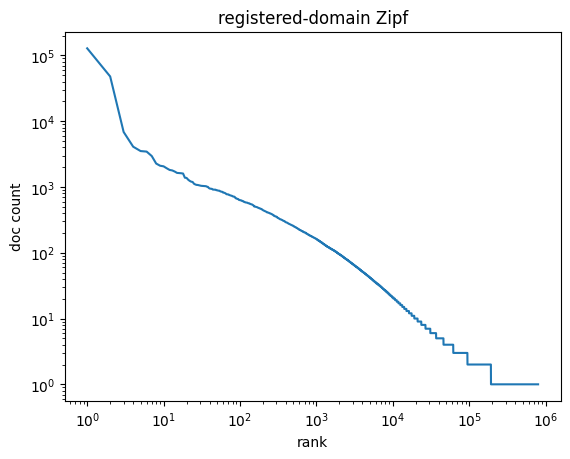

In [7]:
# zipf curve for urls!
vc = df.url_registered_domain.value_counts()
print(f'unique: {len(vc):,}   >=100 docs: {(vc>=100).sum():,}   >=1000 docs: {(vc>=1000).sum():,}')
plt.loglog(range(1, len(vc)+1), vc.values)
plt.xlabel('rank'); plt.ylabel('doc count'); plt.title('registered-domain Zipf')

In [8]:
vc.head(30)

url_registered_domain
blogspot.com           127798
wordpress.com           47710
wikia.com                6841
cbslocal.com             4086
urbandictionary.com      3509
stackexchange.com        3443
wikipedia.org            2948
yahoo.com                2266
blogspot.co.uk           2100
typepad.com              2056
wsj.com                  1920
cnn.com                  1812
nytimes.com              1780
theguardian.com          1712
livejournal.com          1634
go.com                   1624
mlb.com                  1614
latimes.com              1597
reuters.com              1381
chicagotribune.com       1370
blogspot.ca              1287
bbc.co.uk                1235
washingtonpost.com       1202
nih.gov                  1189
tumblr.com               1118
cnet.com                 1091
fool.com                 1074
hotels.com               1071
businessinsider.com      1060
ancestry.com             1049
Name: count, dtype: int64

## inspect a few docs end to end

In [9]:
# Inspect a few docs end-to-end (URL + all features)
df.sample(3, random_state=0).T

,1917270,406186,662936
doc_idx,30412,10263,7004
url,https://prestonhollow.bubblelife.com/community...,http://www.wcbi.com/wordpress/video-liquor-leg...,https://www.beedictionary.com/definition/abstr...
url_netloc,prestonhollow.bubblelife.com,wcbi.com,beedictionary.com
url_registered_domain,bubblelife.com,wcbi.com,beedictionary.com
char_count,1796,798,542
word_count,265,130,87
mean_word_length,5.641509,5.092308,5.103448
frac_alpha,0.776169,0.796992,0.774908
frac_digit,0.024499,0.007519,0.0
frac_punctuation,0.030624,0.022556,0.038745


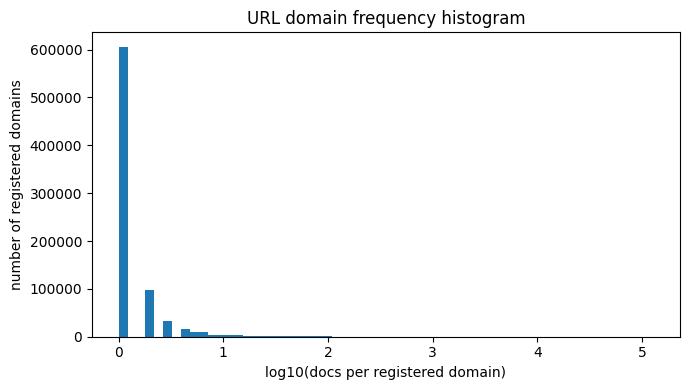

In [10]:
# histogram of docs per registered domain
domain_counts = df.url_registered_domain.value_counts()
plt.figure(figsize=(7, 4))
plt.hist(np.log10(domain_counts), bins=60)
plt.xlabel('log10(docs per registered domain)')
plt.ylabel('number of registered domains')
plt.title('URL domain frequency histogram')
plt.tight_layout()